In [1]:
import warnings
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Iterable
from cuml import LogisticRegression
from cuml import metrics as cl_metrics
from sklearn import metrics
%matplotlib inline

import cudf

warnings.filterwarnings('ignore')

DATA_PATH = './../data_numpy'
BEST_PARAM_PATH = './../best_params/LR'

Xtr = pd.read_csv(f'{DATA_PATH}/Xtr_encoded.csv')
Xval = pd.read_csv(f'{DATA_PATH}/Xval_encoded.csv')
Xte = pd.read_csv(f'{DATA_PATH}/Xte_encoded.csv')
ytr = pd.read_csv(f'{DATA_PATH}/ytr_encoded.csv')
yval = pd.read_csv(f'{DATA_PATH}/yval_encoded.csv')
yte = pd.read_csv(f'{DATA_PATH}/yte_encoded.csv')

# Oversampled version
Xtr_oversampled = pd.read_csv(f'{DATA_PATH}/Xtr_encoded_oversampled.csv')
Xval_oversampled = pd.read_csv(f'{DATA_PATH}/Xval_encoded_oversampled.csv')
Xte_oversampled = pd.read_csv(f'{DATA_PATH}/Xte_encoded_oversampled.csv')
ytr_oversampled = pd.read_csv(f'{DATA_PATH}/ytr_encoded_oversampled.csv')
yval_oversampled = pd.read_csv(f'{DATA_PATH}/yval_encoded_oversampled.csv')
yte_oversampled = pd.read_csv(f'{DATA_PATH}/yte_encoded_oversampled.csv')

In [2]:
Xtr = cudf.DataFrame(Xtr)
Xval = cudf.DataFrame(Xval)
Xte = cudf.DataFrame(Xte)
ytr = cudf.Series(ytr)
yval = cudf.Series(yval)
yte = cudf.Series(yte)

Xtr_oversampled = cudf.DataFrame(Xtr_oversampled)
Xval_oversampled = cudf.DataFrame(Xval_oversampled)
Xte_oversampled = cudf.DataFrame(Xte_oversampled)
ytr_oversampled = cudf.Series(ytr_oversampled)
yval_oversampled = cudf.Series(yval_oversampled)
yte_oversampled = cudf.Series(yte_oversampled)

# Weighted Logistic Regression

It's a variant of the standard logistic regression which is more suitable in imbalanced datasets 
scenarios. The standard LR would penalize the minority class too much, leading to a lower true 
positive rate (TPR).

The Weighted Logistic Regression assigns an "importance" (so a weight) to both the classes of the 
dataset based on their distribution in the dataset (lower prevalence $\to$ higher weight), so that 
the model "focuses" on predicting the minority class more correctly, rather than the majority one.

In [3]:
# calculate class weights
pos = np.sum(ytr == 1)
neg = np.sum(ytr == 0)
pr = pos / (pos + neg)  # positive rate
nr = 1 - pr  # negative rate
WEIGHTS = {0: pr, 1: nr}  # final weights (minority class weighted higher)
print(f"fraud rate: {pr} ~ {pr:.3%}\nnon-fraud rate: {nr} ~ {nr:.3%}")

fraud rate: 0.010008146512116262 ~ 1.001%
non-fraud rate: 0.9899918534878838 ~ 98.999%


## Cross Validation

I decided to exploit the time factor to use a portion of the entire dataset as validation set

In [4]:
lams = np.linspace(1, 500, 500)


def CV(
        Xtr: pd.DataFrame, ytr: pd.Series,
        Xval: pd.DataFrame, yval: pd.Series,
        lams: Iterable,
        weights=WEIGHTS
):
    best_score = -1
    best_lam = None
    i = 1

    fits = len(lams)

    for lam in lams:
        timer = time.time()

        # train the model with different parameters
        model = LogisticRegression(class_weight=weights, C=lam)
        model.fit(Xtr, ytr)

        # calculate the score
        # probabilities for class 1
        y_pred = model.predict_proba(Xval)[1]
        score = cl_metrics.roc_auc_score(yval, y_pred)

        end = time.time() - timer
        elapsed_time = f"{end:.1f}s" if end < 60 else f"{(end / 60):.1f}min"
        print(
            f"[fit {i}/{fits}] END {lam=}, score = {score:.6f} total time = {elapsed_time}")
        i += 1

        if score > best_score:
            best_score = score
            best_lam = lam

    print(f"Best lam: {best_lam}")
    print(f"Best roc_auc score: {best_score}")

    return best_lam, best_score

In [5]:
choice = input("Do you want to execute this cell? (yes/no): ")

if choice.lower() == "yes":
    print("Executing cross validation...")
    best_lam, best_score = CV(Xtr, ytr, Xval, yval, lams, weights=WEIGHTS)
    np.save(f'{BEST_PARAM_PATH}/best_lam.npy', best_lam)
else:
    print("Loading data locally...")
    best_lam = np.load(f'{BEST_PARAM_PATH}/best_lam.npy')

print("\nBest lambda:", best_lam)
print("Best score:", best_score)

Executing cross validation...
[fit 1/500] END lam=1.0, score = 0.856995 total time = 2.3s
[fit 2/500] END lam=2.0, score = 0.856827 total time = 0.6s
[fit 3/500] END lam=3.0, score = 0.857239 total time = 0.6s
[fit 4/500] END lam=4.0, score = 0.857775 total time = 0.5s
[fit 5/500] END lam=5.0, score = 0.857087 total time = 0.6s
[fit 6/500] END lam=6.0, score = 0.856945 total time = 0.6s
[fit 7/500] END lam=7.0, score = 0.857196 total time = 0.6s
[fit 8/500] END lam=8.0, score = 0.857080 total time = 0.6s
[fit 9/500] END lam=9.0, score = 0.856965 total time = 0.6s
[fit 10/500] END lam=10.0, score = 0.856949 total time = 0.5s
[fit 11/500] END lam=11.0, score = 0.857007 total time = 0.6s
[fit 12/500] END lam=12.0, score = 0.857041 total time = 0.5s
[fit 13/500] END lam=13.0, score = 0.857013 total time = 0.4s
[fit 14/500] END lam=14.0, score = 0.856962 total time = 0.6s
[fit 15/500] END lam=15.0, score = 0.857632 total time = 0.6s
[fit 16/500] END lam=16.0, score = 0.857222 total time = 0

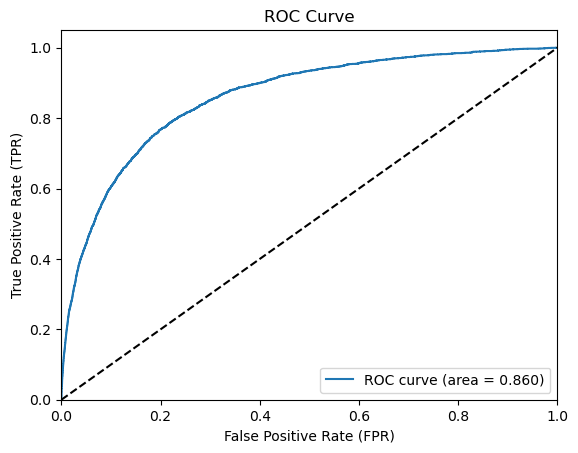

In [6]:
model = LogisticRegression(class_weight=WEIGHTS, C=best_lam)
model.fit(Xtr, ytr)
y_pred = model.predict_proba(Xte)[1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte.to_numpy(), y_pred.to_numpy())
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

## Oversampled datasets

In [9]:
# calculate class weights
pos = np.sum(ytr_oversampled == 1)
neg = np.sum(ytr_oversampled == 0)
pr = pos / (pos + neg)  # positive rate
nr = 1 - pr  # negative rate
WEIGHTS = {0: pr, 1: nr}  # final weights (minority class weighted higher)
print(f"fraud rate: {pr} ~ {pr:.3%}\nnon-fraud rate: {nr} ~ {nr:.3%}")

fraud rate: 0.4766063223006447 ~ 47.661%
non-fraud rate: 0.5233936776993553 ~ 52.339%


In [10]:
choice = input("Do you want to execute this cell? (yes/no): ")

if choice.lower() == "yes":
    print("Executing cross validation...")
    best_lam, best_score = CV(Xtr_oversampled, ytr_oversampled, Xval_oversampled, yval_oversampled, lams, weights=WEIGHTS)
    np.save(f'{BEST_PARAM_PATH}/../oversampling/LR/best_lam.npy', best_lam)
else:
    print("Loading data locally...")
    best_lam = np.load(f'{BEST_PARAM_PATH}/../oversampling/LR/best_lam.npy')

print("\nBest lambda:", best_lam)
print("Best score:", best_score)

Executing cross validation...
[fit 1/500] END lam=1.0, score = 0.872332 total time = 2.6s
[fit 2/500] END lam=2.0, score = 0.872422 total time = 2.8s
[fit 3/500] END lam=3.0, score = 0.872401 total time = 3.0s
[fit 4/500] END lam=4.0, score = 0.872411 total time = 2.8s
[fit 5/500] END lam=5.0, score = 0.872397 total time = 2.6s
[fit 6/500] END lam=6.0, score = 0.872406 total time = 2.7s
[fit 7/500] END lam=7.0, score = 0.872404 total time = 2.7s
[fit 8/500] END lam=8.0, score = 0.872424 total time = 2.8s
[fit 9/500] END lam=9.0, score = 0.872402 total time = 2.4s
[fit 10/500] END lam=10.0, score = 0.872393 total time = 2.5s
[fit 11/500] END lam=11.0, score = 0.872393 total time = 2.4s
[fit 12/500] END lam=12.0, score = 0.872406 total time = 2.9s
[fit 13/500] END lam=13.0, score = 0.872409 total time = 2.7s
[fit 14/500] END lam=14.0, score = 0.872403 total time = 2.7s
[fit 15/500] END lam=15.0, score = 0.872382 total time = 2.6s
[fit 16/500] END lam=16.0, score = 0.872384 total time = 2

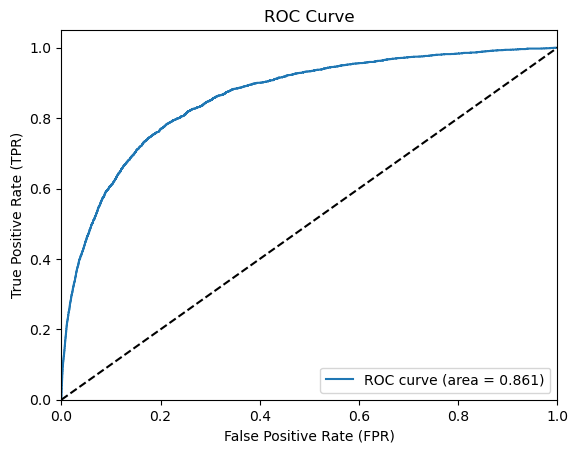

In [11]:
model = LogisticRegression(class_weight=WEIGHTS, C=best_lam)
model.fit(Xtr, ytr)
y_pred = model.predict_proba(Xte)[1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte.to_numpy(), y_pred.to_numpy())
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()